In [1]:
import pandas as pd

val_results_path: str = "../data.nosync/results_sklearn_nested_regression.nosync/uncertainties_validation-PARTIAL.parquet"
val_results = pd.read_parquet(val_results_path)
# select only rows whose index values of 'task_name' is 'cars'
# val_results = val_results.loc[val_results.index.get_level_values('task_name') == 'cars']

In [136]:
val_results

variances  \
outer_fold inner_fold task_name task_num alpha mcdropout_num num_layers dropout_rate output_size                     
0          0          cars      361622   0.001 3             1          0.001        1           0    0.000000e+00   
                                                                                                 1    3.155444e-30   
                                                                                                 2    0.000000e+00   
                                                                                                 3    0.000000e+00   
                                                                                                 4    0.000000e+00   
...                                                                                                            ...   
2          2          cars      361622   1.000 1000          10         0.900        1           173  8.622796e+05   
                                                                                                 174  7.223245e+05   
                                                                                                 175  5.854167e+05   
                                                                                                 176  8.024728e+05   
                                                                                                 177  7.947479e+05   

                                                                                                      outlier_vals  \
outer_fold inner_fold task_name task_num alpha mcdropout_num num_layers dropout_rate output_size                     
0          0          cars      361622   0.001 3             1          0.001        1           0       -0.467902   
                                                                                                 1       -0.558253   
                                                                                                 2       -0.565455   
                                                                                                 3       -0.447999   
                                                                                                 4       -0.490865   
...                                                                                                            ...   
2          2          cars      361622   1.000 1000          10         0.900        1           173     -0.481455   
                                                                                                 174     -0.507403   
                                                                                                 175     -0.462851   
                                                                                                 176     -0.402916   
                                                                                                 177     -0.541736   

                                                                                                      anomaly_vals  
outer_fold inner_fold task_name task_num alpha mcdropout_num num_layers dropout_rate output_size                    
0          0          cars      361622   0.001 3             1          0.001        1           0       -0.966923  
                                                                                                 1       -1.147702  
                                                                                                 2       -1.148286  
                                                                                                 3       -1.005335  
                                                                                                 4       -1.038854  
...                                                                                                            ...  
2          2          cars      361622   1.000 1000          10         0.900        1           17

In [2]:
val_results.reset_index(inplace=True)

In [27]:
from tqdm.notebook import tqdm
tqdm.pandas(desc='Computing Standard Uncertainty')

def compute_zscore(x):
    std_variances: pd.Series = (x["variances"] - x["variances"].mean()) / x["variances"].std()
    # std_variances: pd.Series = x["variances"] / (x["variances"].max() - x["variances"].min())
    # add p values as index to std_variances
    return pd.DataFrame([std_variances, x["dropout_rate"]]).T

val_results_high_acc = val_results[val_results['mcdropout_num'] == 1000]
data_grouped = (val_results_high_acc
                .groupby(["task_name", "num_layers"])
                .progress_apply(compute_zscore))

Computing Standard Uncertainty:   0%|          | 0/52 [00:00<?, ?it/s]

In [34]:
colors_list = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'black', 'magenta', 'lime', 'teal', 'coral', 'lightblue', 'lightgreen', 'lavender', 'tan', 'salmon', 'gold', 'darkred', 'darkgreen', 'darkblue', 'darkorange', 'darkpurple', 'darkbrown', 'darkpink', 'darkgray', 'darkolive', 'darkcyan', 'darkblack', 'darkyellow', 'darkmagenta', 'darklime', 'darkteal', 'darkcoral', 'darklightblue', 'darklightgreen', 'darklavender', 'darktan', 'darksalmon', 'darkgold', 'darkred', 'darkgreen', 'darkblue', 'darkorange', 'darkpurple', 'darkbrown', 'darkpink', 'darkgray', 'darkolive', 'darkcyan', 'darkblack', 'darkyellow', 'darkmagenta', 'darklime', 'darkteal', 'darkcoral', 'darklightblue', 'darklightgreen', 'darklavender', 'darktan', 'darksalmon', 'darkgold', 'darkred', 'darkgreen', 'darkblue', 'darkorange', 'darkpurple', 'darkbrown', 'darkpink', 'darkgray', 'darkolive', 'darkcyan', 'darkblack', 'darkyellow', 'darkmagenta', 'darklime', 'darkteal', 'darkcoral', 'darklightblue', 'darklightgreen', 'darklavender', 'darktan', 'darksalmon', 'darkgold', 'darkred', 'darkgreen', 'darkblue', 'darkorange', 'darkpurple', 'darkbrown', 'darkpink', 'darkgray', 'darkolive', 'darkcyan', 'darkblack', 'darkyellow', 'darkmagenta', 'darklime', 'darkteal', 'darkcoral', 'darklightblue', 'darklightgreen', 'darklavender', 'darktan', 'darksalmon', 'darkgold', 'darkred', 'darkgreen', 'darkblue', 'darkorange', 'darkpurple', 'darkbrown', 'darkpink', 'darkgray', 'darkolive', 'darkcyan', 'darkblack', 'darkyellow', 'darkmagenta', 'darklime', 'darkteal', 'darkcoral', 'darklightblue']
task_names = val_results['task_name'].unique()
colors = {
    task_name: color
    for task_name, color in zip(task_names, colors_list[:len(task_names)])
}

linestyles = ['-', '--', '-.', ':', '-', '--', '-.', ':',]
models = val_results['num_layers'].unique()
linestyles_dict = {
    model: linestyle
    for model, linestyle in zip(models, linestyles)
}

/tmp/ipykernel_115119/3230072658.py:23: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  data_to_plot = data_grouped.groupby(["task_name","num_layers"],


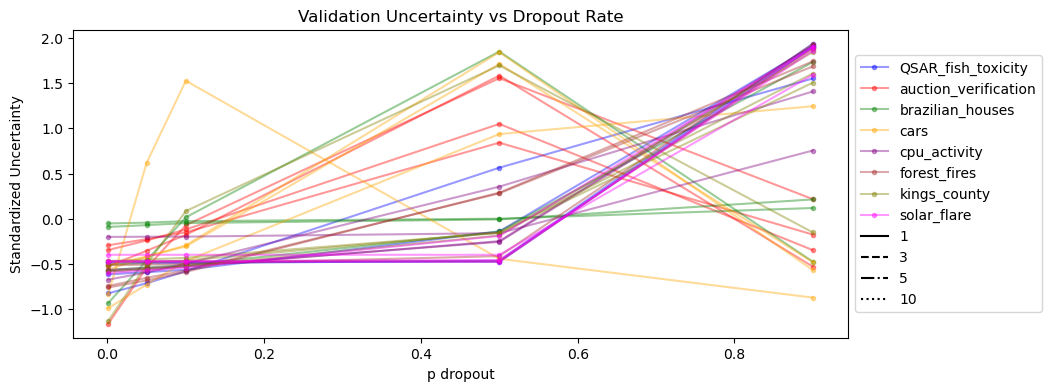

In [38]:
import matplotlib.pyplot as plt
from sklearn.utils._testing import ignore_warnings

figure = plt.figure(figsize=(10, 4))

dropout_values = list(data_grouped["dropout_rate"].unique())

@ignore_warnings(category=DeprecationWarning)
def plot_mean(x):
    task_name, num_layers = x.name
    if x['dropout_rate'].nunique() != len(dropout_values):
        return
    else:
        values = x.groupby('dropout_rate').apply(lambda x: x['variances'].mean())
        plt.plot(values.index, 
                 values.values, 
                 linestyle='-', 
                 marker='.', 
                 alpha=0.4, 
                 color=colors[task_name], 
                 label=task_name)
    
data_to_plot = data_grouped.groupby(["task_name","num_layers"], 
                                    axis=0).apply(plot_mean)
plt.title("Validation Uncertainty vs Dropout Rate")
plt.xlabel("p dropout")
plt.ylabel("Standardized Uncertainty")

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend([* by_label.values(), *[plt.Line2D([0], [0], color='black', linestyle=linestyle) for linestyle in linestyles]], 
           [*by_label.keys(), *models], loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

/tmp/ipykernel_115119/2644661049.py:23: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  data_to_plot = data_grouped.groupby(["task_name",],


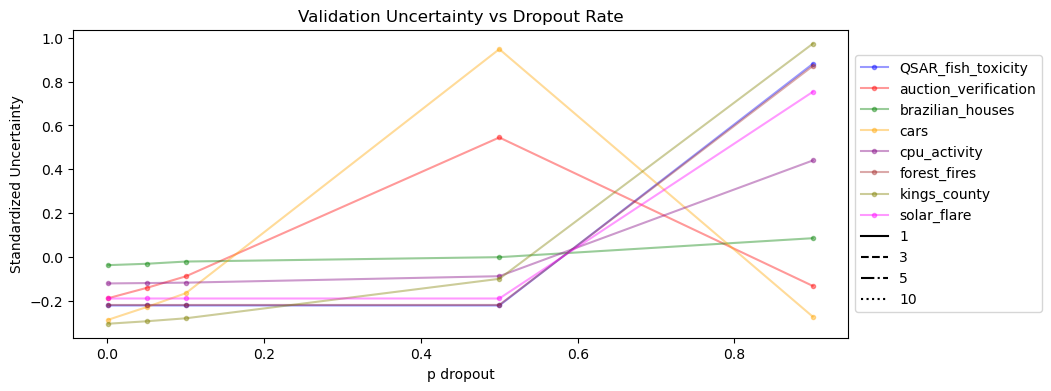

In [24]:
import matplotlib.pyplot as plt
from sklearn.utils._testing import ignore_warnings

figure = plt.figure(figsize=(10, 4))

dropout_values = list(data_grouped["dropout_rate"].unique())

@ignore_warnings(category=DeprecationWarning)
def plot_mean(x):
    task_name = x.name
    if x['dropout_rate'].nunique() != len(dropout_values):
        return
    else:
        values = x.groupby('dropout_rate').apply(lambda x: x['variances'].mean())
        plt.plot(values.index, 
                 values.values, 
                 linestyle='-', 
                 marker='.', 
                 alpha=0.4, 
                 color=colors[task_name], 
                 label=task_name)
    
data_to_plot = data_grouped.groupby(["task_name",], 
                                    axis=0).apply(plot_mean)
plt.title("Validation Uncertainty vs Dropout Rate")
plt.xlabel("p dropout")
plt.ylabel("Standardized Uncertainty")

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend([* by_label.values(), *[plt.Line2D([0], [0], color='black', linestyle=linestyle) for linestyle in linestyles]], 
           [*by_label.keys(), *models], loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.utils._testing import ignore_warnings

figure = plt.figure(figsize=(10, 4))

dropout_values = list(data_grouped["dropout_rate"].unique())

@ignore_warnings(category=DeprecationWarning)
def plot_mean(x):
    task_name, alpha, mcdropout_num, num_layers, outer_fold, inner_fold = x.name
    if x['dropout_rate'].nunique() != len(dropout_values):
        return
    else:
        values = x.groupby('dropout_rate').apply(lambda x: x['variances'].mean())
        plt.plot(values.index, 
                 values.values, 
                 linestyle='-', 
                 marker='.', 
                 alpha=0.2, 
                 color=colors[task_name], 
                 label=task_name)
    
data_to_plot = data_grouped.groupby(["task_name", "alpha", "mcdropout_num", "num_layers", "outer_fold", "inner_fold"], 
                                    axis=0).apply(plot_mean)
plt.title("Validation Uncertainty vs Dropout Rate")
plt.xlabel("p dropout")
plt.ylabel("Standardized Uncertainty")

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.show()

In [ ]:
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm


data_to_plot = val_results[val_results['mcdropout_num'] == 1000]

figure = plt.figure(figsize=(10, 4))

columns_of_interest = [
    "task_name",
    "alpha",
    "mcdropout_num",
    "outer_fold",
    "inner_fold",
]
possible_combinations = data_to_plot[columns_of_interest].drop_duplicates()
possible_task_names = list(possible_combinations["task_name"].unique())
for index, row in tqdm(possible_combinations.iterrows(), desc='Calculating combination avg', total=len(possible_combinations)):
    task_name = row["task_name"]
    alpha = row["alpha"]
    mcdropout_num = row["mcdropout_num"]
    outer_fold = row["outer_fold"]
    inner_fold = row["inner_fold"]
    
    # current index for task_name in possible_task_names
    current_index = possible_task_names.index(task_name)
    mask = (
        (data_to_plot["task_name"] == task_name)
        & (data_to_plot["alpha"] == alpha)
        & (data_to_plot["mcdropout_num"] == mcdropout_num)
        & (data_to_plot["outer_fold"] == outer_fold)
        & (data_to_plot["inner_fold"] == inner_fold)
    )
    data = data_to_plot[mask].copy()
    data['stand variances'] = (data["variances"] - data["variances"].mean()) / data[
        "variances"
    ].std()
    # data['stand variances'] = data["variances"] / (data["variances"].max() - data["variances"].min())
    mean_stand_variances = []
    for unique_dropout_val in data["dropout_rate"].unique():
        mask = data["dropout_rate"] == unique_dropout_val
        mean_stand_variances.append(data[mask]["stand variances"].mean())
        
    if data['dropout_rate'].nunique() != data_to_plot["dropout_rate"].nunique():
        continue
    
    plt.plot(list(data["dropout_rate"].unique()), mean_stand_variances, linestyle='-', marker='.', alpha=0.2, color=colors[current_index], label=task_name)
    # plt.plot(data["dropout_rate"], standardized_variances, linestyle='None', marker='.', alpha=0.2)
plt.title("Validation Uncertainty vs Dropout Rate")
plt.xlabel("p dropout")
plt.ylabel("Standardized Uncertainty")

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.show()

In [17]:
data['dropout_rate'].nunique()

1

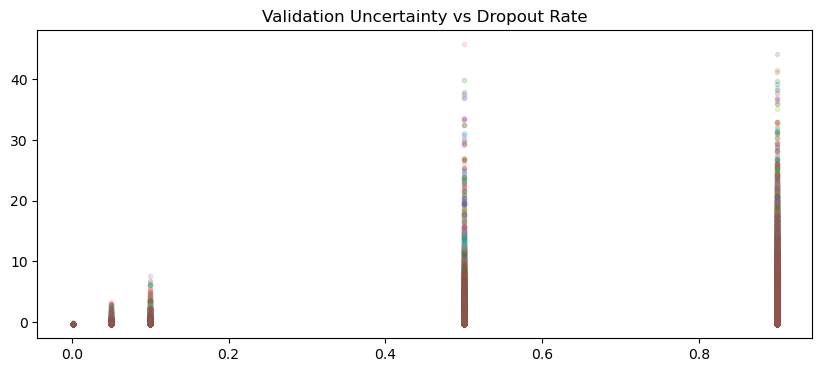

In [4]:
import matplotlib.pyplot as plt


figure = plt.figure(figsize=(10, 4))

columns_of_interest = [
    "task_name",
    "alpha",
    "mcdropout_num",
    "outer_fold",
    "inner_fold",
]
possible_combinations = val_results[columns_of_interest].drop_duplicates()
for index, row in possible_combinations.iterrows():
    task_name = row["task_name"]
    alpha = row["alpha"]
    mcdropout_num = row["mcdropout_num"]
    outer_fold = row["outer_fold"]
    inner_fold = row["inner_fold"]
    mask = (
        (val_results["task_name"] == task_name)
        & (val_results["alpha"] == alpha)
        & (val_results["mcdropout_num"] == mcdropout_num)
        & (val_results["outer_fold"] == outer_fold)
        & (val_results["inner_fold"] == inner_fold)
    )
    data = val_results[mask]
    standardized_variances = (data["variances"] - data["variances"].mean()) / data[
        "variances"
    ].std()
    

    plt.plot(data["dropout_rate"], standardized_variances, linestyle='None', marker='.', alpha=0.2)
plt.title("Validation Uncertainty vs Dropout Rate")
plt.show()

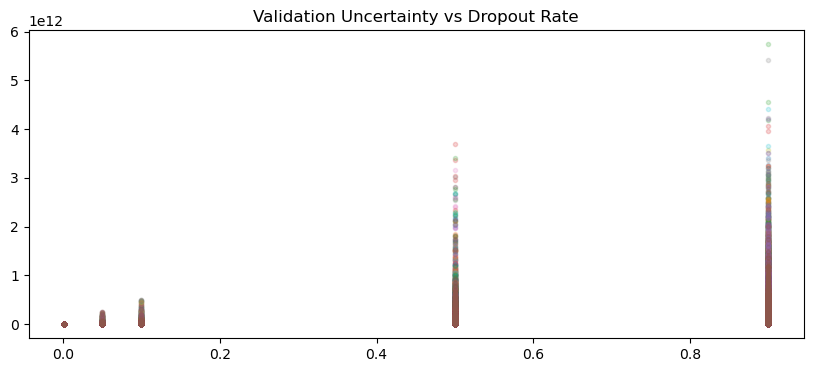

In [5]:
import matplotlib.pyplot as plt


figure = plt.figure(figsize=(10, 4))

columns_of_interest = [
    "task_name",
    "alpha",
    "mcdropout_num",
    "outer_fold",
    "inner_fold",
]
possible_combinations = val_results[columns_of_interest].drop_duplicates()
for index, row in possible_combinations.iterrows():
    task_name = row["task_name"]
    alpha = row["alpha"]
    mcdropout_num = row["mcdropout_num"]
    outer_fold = row["outer_fold"]
    inner_fold = row["inner_fold"]
    mask = (
        (val_results["task_name"] == task_name)
        & (val_results["alpha"] == alpha)
        & (val_results["mcdropout_num"] == mcdropout_num)
        & (val_results["outer_fold"] == outer_fold)
        & (val_results["inner_fold"] == inner_fold)
    )
    data = val_results[mask]

    plt.plot(data["dropout_rate"], data["variances"], linestyle='None', marker='.', alpha=0.2)
plt.title("Validation Uncertainty vs Dropout Rate")
plt.show()

/var/folders/rc/t3h_b88s3vbg5dcd4pnlgskr0000gp/T/ipykernel_29492/3646302673.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['stand variances'] = (data["variances"] - data["variances"].mean()) / data[
/var/folders/rc/t3h_b88s3vbg5dcd4pnlgskr0000gp/T/ipykernel_29492/3646302673.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['stand variances'] = (data["variances"] - data["variances"].mean()) / data[
/var/folders/rc/t3h_b88s3vbg5dcd4pnlgskr0000gp/T/ipykernel_29492/3646302673.py:28: SettingWi

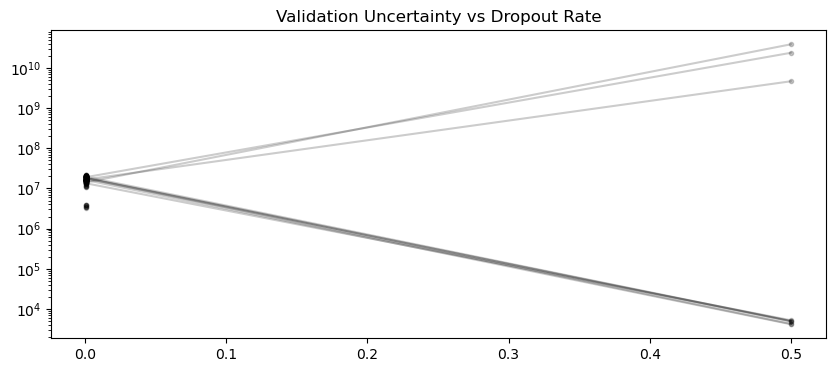

In [11]:
import matplotlib.pyplot as plt


figure = plt.figure(figsize=(10, 4))

columns_of_interest = [
    "task_name",
    "alpha",
    "mcdropout_num",
    "outer_fold",
    "inner_fold",
]
possible_combinations = val_results[columns_of_interest].drop_duplicates()
for index, row in possible_combinations.iterrows():
    task_name = row["task_name"]
    alpha = row["alpha"]
    mcdropout_num = row["mcdropout_num"]
    outer_fold = row["outer_fold"]
    inner_fold = row["inner_fold"]
    mask = (
        (val_results["task_name"] == task_name)
        & (val_results["alpha"] == alpha)
        & (val_results["mcdropout_num"] == mcdropout_num)
        & (val_results["outer_fold"] == outer_fold)
        & (val_results["inner_fold"] == inner_fold)
    )
    data = val_results[mask]
    data['stand variances'] = (data["variances"] - data["variances"].mean()) / data[
        "variances"
    ].std()
    mean_variances = []
    for unique_dropout_val in data["dropout_rate"].unique():
        mask = data["dropout_rate"] == unique_dropout_val
        mean_variances.append(data[mask]["variances"].mean())
    
    plt.plot(list(data["dropout_rate"].unique()), mean_variances, linestyle='-', marker='.', alpha=0.2, color='black')
    # plt.plot(data["dropout_rate"], standardized_variances, linestyle='None', marker='.', alpha=0.2)
plt.title("Validation Uncertainty vs Dropout Rate")
# set y axis logscale
plt.yscale('log')
plt.show()